# High-Entropy Alloy (Fe–Co–Cr–Mn–Cu) Overpotential — Exploratory Data Analysis & SHAP Interpretation

This notebook consolidates **every EDA method used across our experiments** into one place,
plus a SHAP interpretation of the resulting patterns. The goal here is analysis, not model
comparison — a single reference model is fit only so SHAP has something to explain.

**Dataset:** 70 alloy compositions, 5 base elemental fractions (Fe, Co, Cr, Mn, Cu) + 22 engineered
polynomial/interaction terms (27 features total), target = Overpotential (mV).

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LassoCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

COMP_COLS = ['Fe', 'Co', 'Cr', 'Mn', 'Cu']
TARGET = 'Overpotential'

## 2. Load Data

In [2]:
df = pd.read_excel('dataset_with_selected_25_features.xlsx')
print("Shape:", df.shape)
df.head()

Shape: (70, 28)


,Fe,Co,Cr,Mn,Cu,Cr^2,Fe^2,Cu^2,Cr*Fe,Cr*Cu,...,Cu*Fe*Mn,Co*Cu*Fe,Co*Fe*Mn,Cr*Cu*Fe*Mn,Co*Cr*Cu*Fe,Co*Cr*Fe*Mn,Co*Cr*Cu*Mn,Co*Cu*Fe*Mn,Co*Cr*Cu*Fe*Mn,Overpotential
0,0.1,0.1,0.6,0.1,0.1,0.36,0.01,0.01,0.06,0.06,...,0.001,0.001,0.001,0.0006,0.0006,0.0006,0.0006,0.0001,0.00006,301.0
1,0.5,0.5,0.0,0.0,0.0,0.00,0.25,0.00,0.00,0.00,...,0.000,0.000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00000,365.0
2,0.0,1.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00000,370.0
3,0.0,0.0,0.0,1.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00000,379.0
4,0.2,0.0,0.5,0.1,0.2,0.25,0.04,0.04,0.10,0.10,...,0.004,0.000,0.000,0.0020,0.0000,0.0000,0.0000,0.0000,0.00000,311.0


## 3. Exploratory Data Analysis

### 3.1 Data Integrity Checks

In [3]:
print("Total missing values:", df.isnull().sum().sum())
print("Fully duplicated rows:", df.duplicated().sum())
print("Data types:\n", df.dtypes.value_counts())
assert np.allclose(df[COMP_COLS].sum(axis=1), 1.0), "Composition fractions should sum to 1"
print("\nComposition fractions confirmed to sum to 1.0 for all rows (valid mixture design).")

Total missing values: 0
Fully duplicated rows: 0
Data types:
 float64    28
Name: count, dtype: int64

Composition fractions confirmed to sum to 1.0 for all rows (valid mixture design).


### 3.2 Descriptive Statistics

In [4]:
df.describe()

,Fe,Co,Cr,Mn,Cu,Cr^2,Fe^2,Cu^2,Cr*Fe,Cr*Cu,...,Cu*Fe*Mn,Co*Cu*Fe,Co*Fe*Mn,Cr*Cu*Fe*Mn,Co*Cr*Cu*Fe,Co*Cr*Fe*Mn,Co*Cr*Cu*Mn,Co*Cu*Fe*Mn,Co*Cr*Cu*Fe*Mn,Overpotential
count,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,...,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000
mean,0.186429,0.205000,0.198571,0.212857,0.197143,0.088214,0.079536,0.084000,0.025143,0.027179,...,0.003032,0.003396,0.002668,0.000294,0.000319,0.000295,0.000274,0.000289,0.000021,349.221429
std,0.213141,0.218053,0.222465,0.232766,0.213983,0.169436,0.153500,0.151031,0.042673,0.046950,...,0.005616,0.006118,0.004936,0.000593,0.000680,0.000592,0.000650,0.000570,0.000043,29.027178
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,286.000000
25%,0.000000,0.000000,0.100000,0.000000,0.000000,0.010000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,332.250000
50%,0.100000,0.100000,0.100000,0.100000,0.100000,0.010000,0.010000,0.010000,0.010000,0.010000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,353.250000
75%,0.300000,0.350000,0.300000,0.400000,0.337500,0.090000,0.090000,0.114375,0.035000,0.035000,...,0.003875,0.005500,0.003500,0.000350,0.000350,0.000350,0.000075,0.000288,0.000000,369.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.250000,0.250000,...,0.024000,0.024000,0.024000,0.002400,0.002700,0.002400,0.003906,0.002400,0.000160,408.000000


### 3.3 Duplicate-Composition Check — Establishing the Measurement Noise Floor

Rows sharing the *exact same* elemental composition should, in principle, give the same Overpotential. Any spread between them reveals the practical noise floor of the measurement itself — a ceiling on how good any model can ever be.

In [5]:
dup = df[df.duplicated(subset=COMP_COLS, keep=False)]
print(f"Rows sharing identical composition: {len(dup)}")
dup.sort_values(COMP_COLS)[COMP_COLS + [TARGET]]

Rows sharing identical composition: 4


,Fe,Co,Cr,Mn,Cu,Overpotential
11,0.1,0.1,0.1,0.1,0.6,335.0
60,0.1,0.1,0.1,0.1,0.6,311.0
15,0.1,0.6,0.1,0.1,0.1,353.5
62,0.1,0.6,0.1,0.1,0.1,355.0


### 3.4 Target Distribution and Top Correlated Features

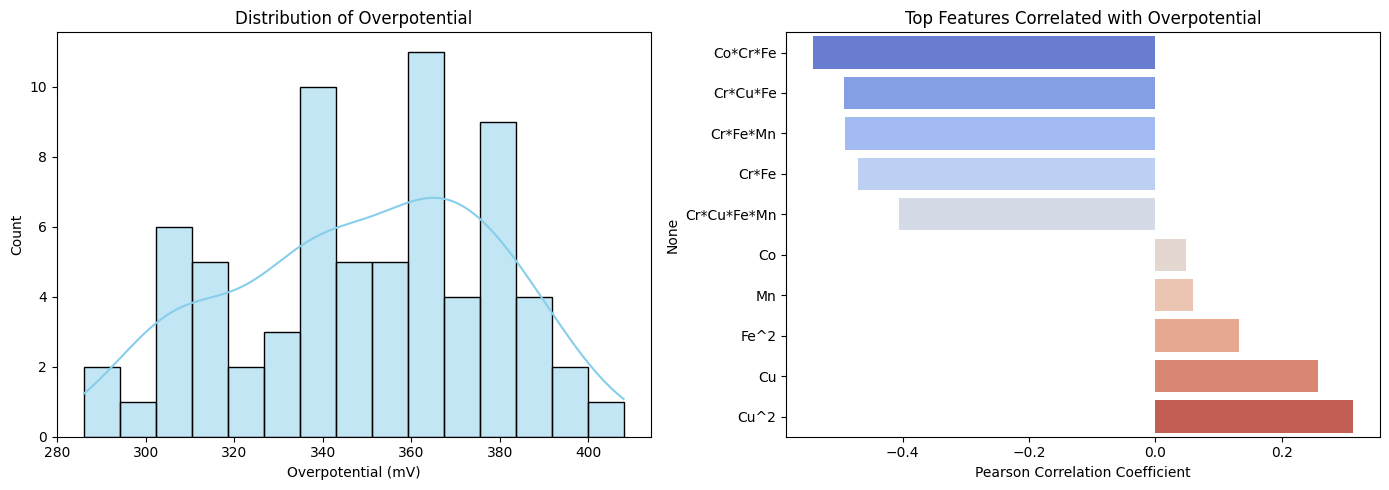

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[TARGET], bins=15, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Overpotential')
axes[0].set_xlabel('Overpotential (mV)')

corr = df.corr()[TARGET].sort_values()
top_corr = pd.concat([corr.head(5), corr.tail(6)]).drop(TARGET)
sns.barplot(x=top_corr.values, y=top_corr.index, ax=axes[1], palette='coolwarm')
axes[1].set_title('Top Features Correlated with Overpotential')
axes[1].set_xlabel('Pearson Correlation Coefficient')

plt.tight_layout()
plt.show()

### 3.5 Full Feature Correlation Heatmap (27 features)

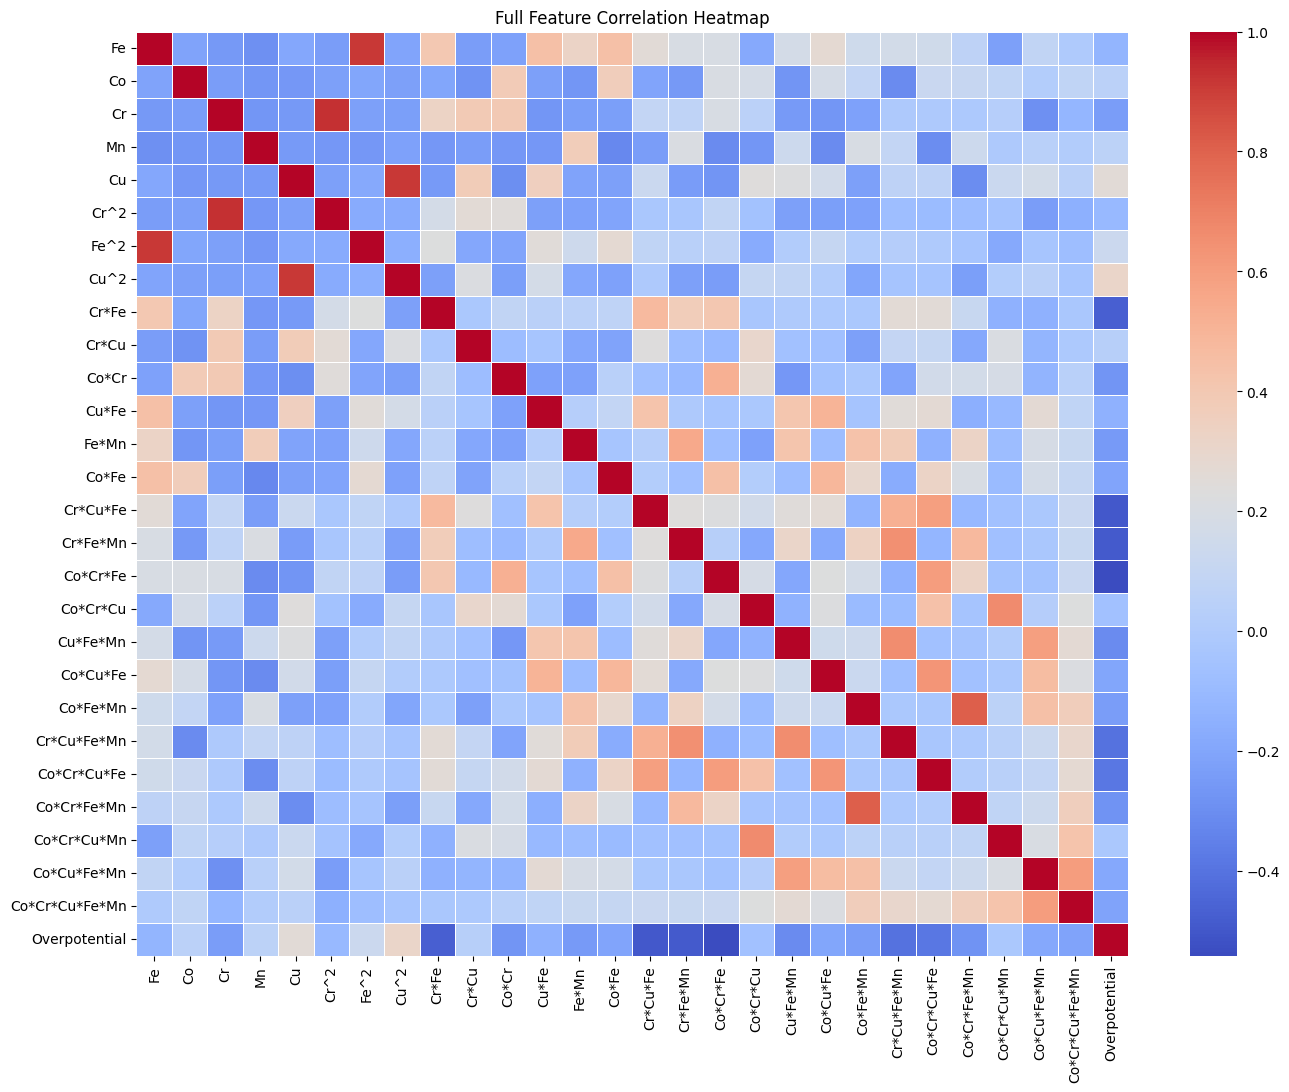

In [7]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Full Feature Correlation Heatmap')
plt.show()

### 3.6 Feature Distributions and Outlier Check

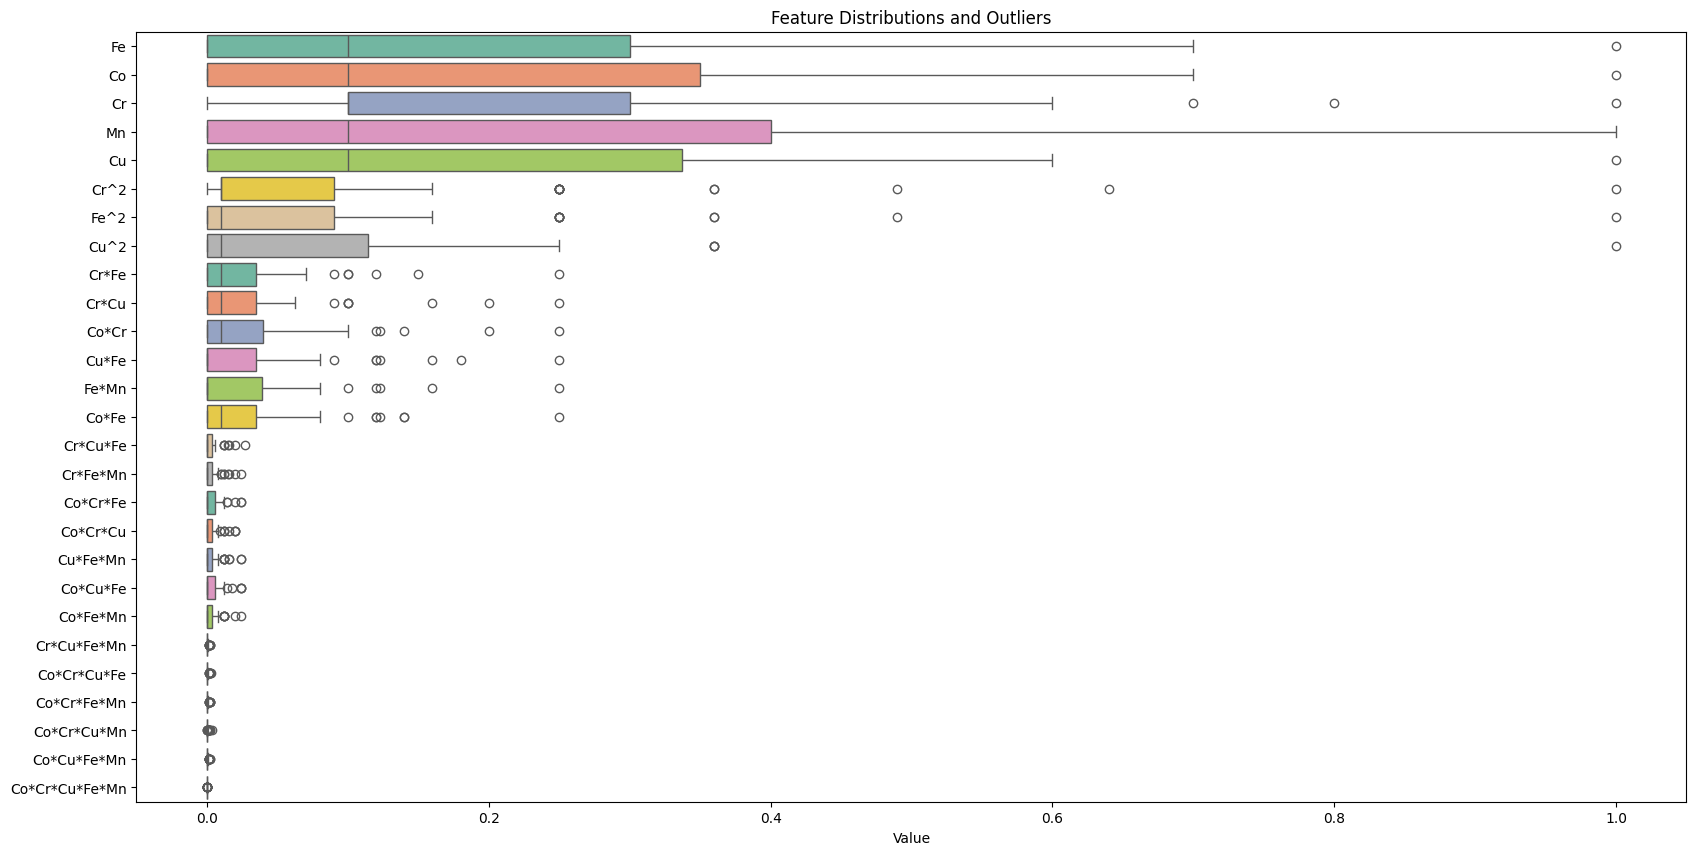

In [8]:
features = df.drop(columns=[TARGET])
plt.figure(figsize=(20, 10))
sns.boxplot(data=features, orient='h', palette='Set2')
plt.title('Feature Distributions and Outliers')
plt.xlabel('Value')
plt.show()

### 3.7 Pairwise Relationships — Base Elements vs. Target

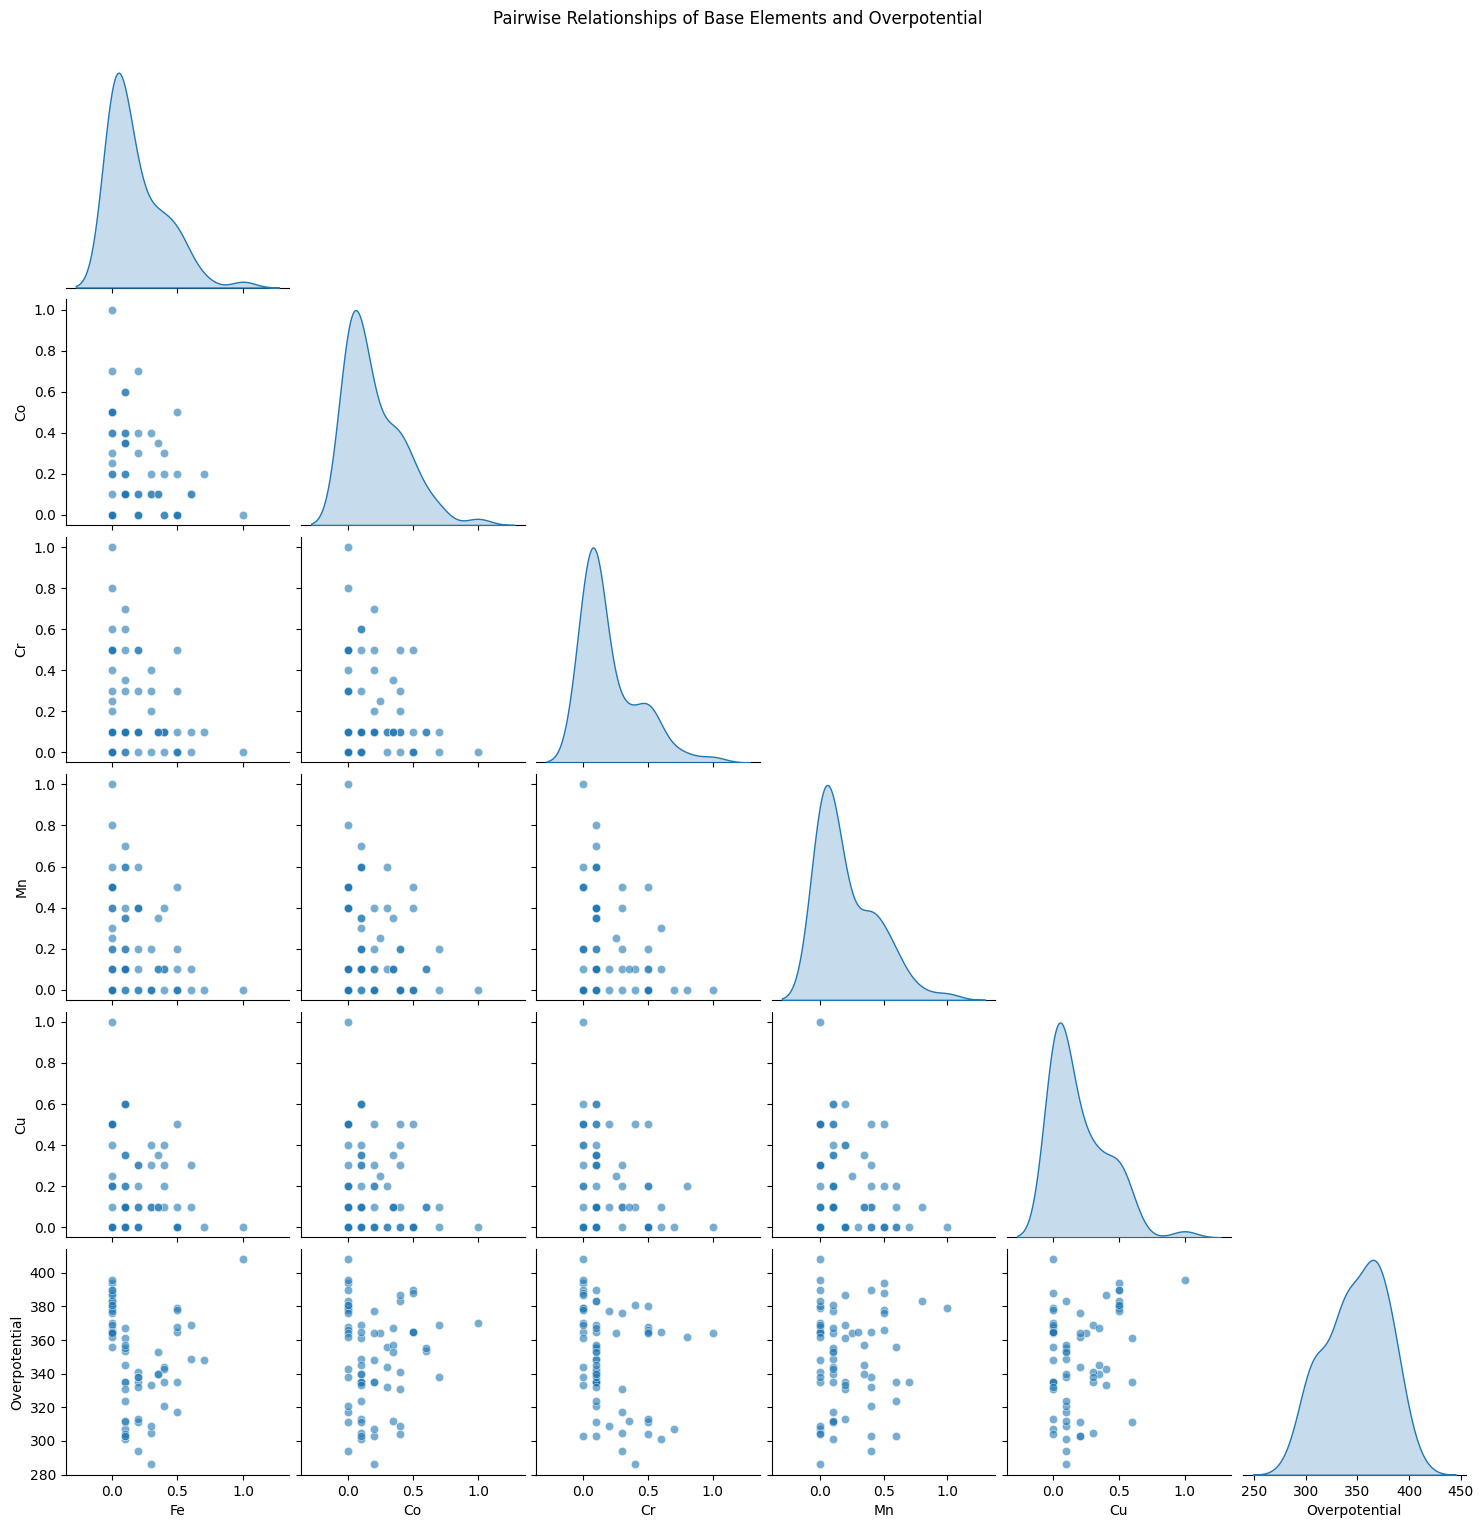

In [9]:
base_df = df[COMP_COLS + [TARGET]]
sns.pairplot(base_df, diag_kind='kde', corner=True, plot_kws={'alpha': 0.6})
plt.suptitle('Pairwise Relationships of Base Elements and Overpotential', y=1.02)
plt.show()

### 3.8 Multicollinearity Check (VIF)

Since the 5 composition fractions must sum to 1, some multicollinearity is expected by construction. VIF quantifies how much.

In [10]:
X_all = df.drop(columns=[TARGET])
vif_data = pd.DataFrame()
vif_data["Feature"] = X_all.columns
vif_data["VIF"] = [variance_inflation_factor(X_all.values, i) for i in range(len(X_all.columns))]
vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True).head(10)

,Feature,VIF
0,Fe,1.000800e+15
1,Co,1.000800e+15
2,Cr,1.000800e+15
3,Mn,1.000800e+15
4,Cu,1.000800e+15
5,Fe^2,1.000800e+15
6,Cr*Fe,1.000800e+15
7,Fe*Mn,1.000800e+15
8,Co*Fe,1.000800e+15
9,Cu*Fe,1.000800e+15


### 3.9 PCA Projection — Visualizing Structure in the Composition Space

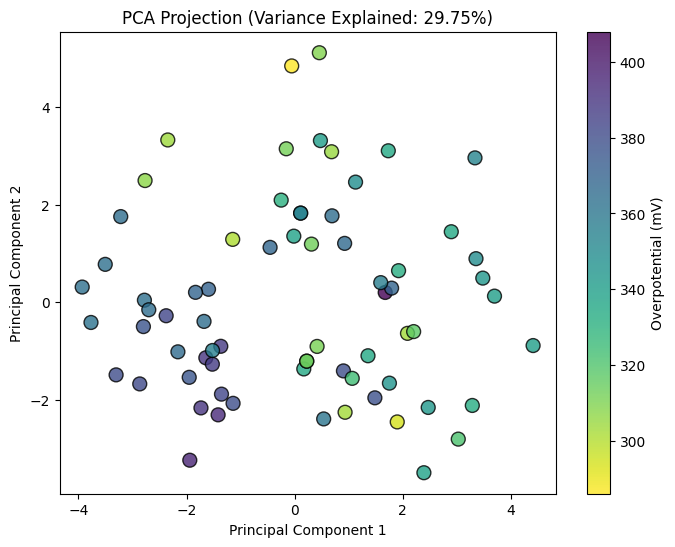

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=[TARGET]))

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1],
                      c=df[TARGET], cmap='viridis_r', s=100, edgecolor='k', alpha=0.8)
plt.colorbar(scatter, label='Overpotential (mV)')
plt.title(f'PCA Projection (Variance Explained: {sum(pca.explained_variance_ratio_):.2%})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### 3.10 Unsupervised Clustering — Do Compositions Form Natural Groups?

--- Overpotential Statistics by Composition Cluster ---


,Cluster,mean,median,count
0,0,363.171875,365.5,32
1,1,342.238095,341.0,21
2,2,331.588235,335.0,17


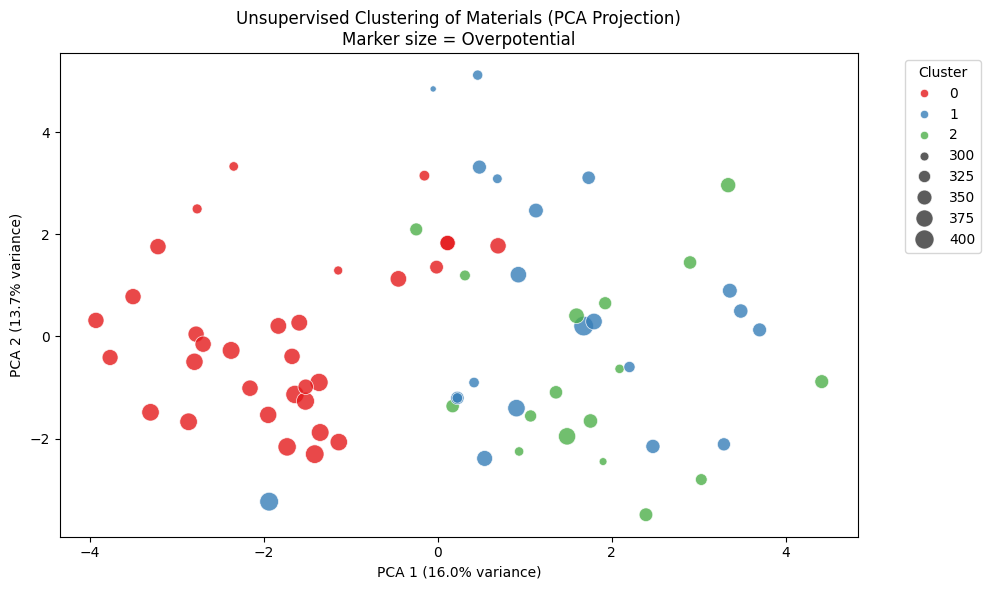

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

cluster_stats = df.assign(Cluster=cluster_labels).groupby('Cluster')[TARGET].agg(['mean', 'median', 'count']).reset_index()
print("--- Overpotential Statistics by Composition Cluster ---")
display(cluster_stats)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=cluster_labels, palette='Set1',
                 size=df[TARGET], sizes=(20, 200), alpha=0.8)
plt.title('Unsupervised Clustering of Materials (PCA Projection)\nMarker size = Overpotential')
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3.11 Exploratory Feature Relevance via Lasso

A quick, independent check on which features look predictive — not used to prune features for modeling (that was tried separately and hurt performance), just as another lens on the data.

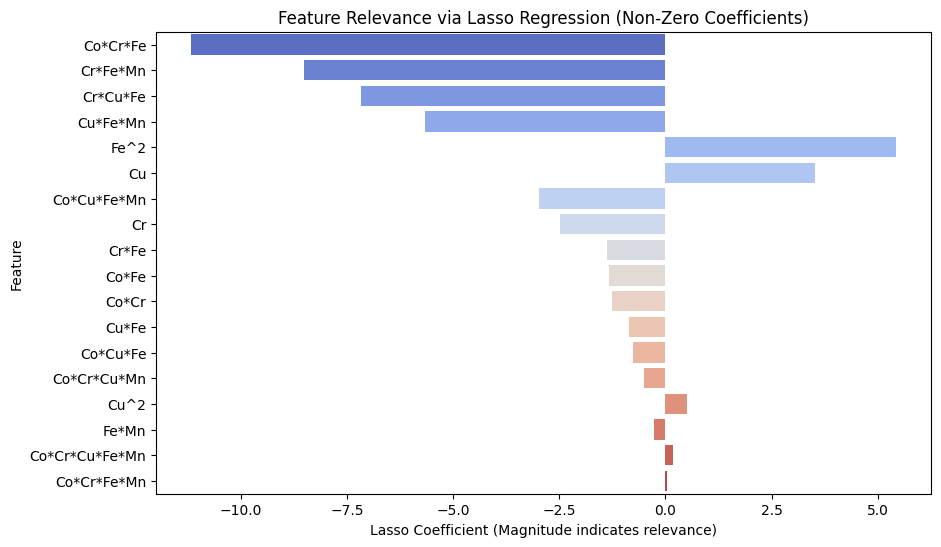

Lasso flagged 18 of 27 features as non-zero.


In [13]:
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_scaled, df[TARGET])

lasso_coefs = pd.DataFrame({'Feature': df.drop(columns=[TARGET]).columns, 'Coefficient': lasso.coef_})
important_features = lasso_coefs[lasso_coefs['Coefficient'] != 0].sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=important_features, palette='coolwarm')
plt.title('Feature Relevance via Lasso Regression (Non-Zero Coefficients)')
plt.xlabel('Lasso Coefficient (Magnitude indicates relevance)')
plt.show()

print(f"Lasso flagged {len(important_features)} of {X_scaled.shape[1]} features as non-zero.")

### EDA Summary

- **Data integrity:** no missing values, no duplicate rows, all composition fractions sum to
  exactly 1.0 — confirms a valid mixture design.
- **Noise floor:** two composition pairs are exact duplicates yet differ by up to ~24 mV in
  measured Overpotential — this sets a practical ceiling of ~15–25 mV on any model's error.
- **Correlation structure:** individual elements correlate weakly with the target; multi-element
  interaction terms (Cr·Fe, Co·Cr·Fe, etc.) correlate far more strongly — a mixture "cocktail
  effect," not a single-element effect.
- **Multicollinearity:** present among the base composition fractions (expected, since they sum
  to 1) — informs the choice of model family later.
- **PCA / clustering:** no sharp natural clusters emerge; composition space is fairly continuous,
  with Overpotential varying smoothly across it rather than by discrete group.
- **Lasso relevance check:** converges on largely the same features later confirmed by SHAP
  below — an early independent signal pointing the same direction.

## 4. Reference Model (for SHAP only)

A single tuned XGBoost model, fit on all data — not a model comparison. This exists purely to give SHAP something to explain.

In [14]:
final_model = xgb.XGBRegressor(n_estimators=250, max_depth=2, learning_rate=0.05, subsample=0.7,
                                colsample_bytree=0.8, reg_lambda=1.0, random_state=42, verbosity=0)
final_model.fit(df.drop(columns=[TARGET]), df[TARGET])
print("Reference model fit on all", df.shape[0], "samples.")

Reference model fit on all 70 samples.


## 5. SHAP Interpretation

### 5.1 SHAP Summary Plot

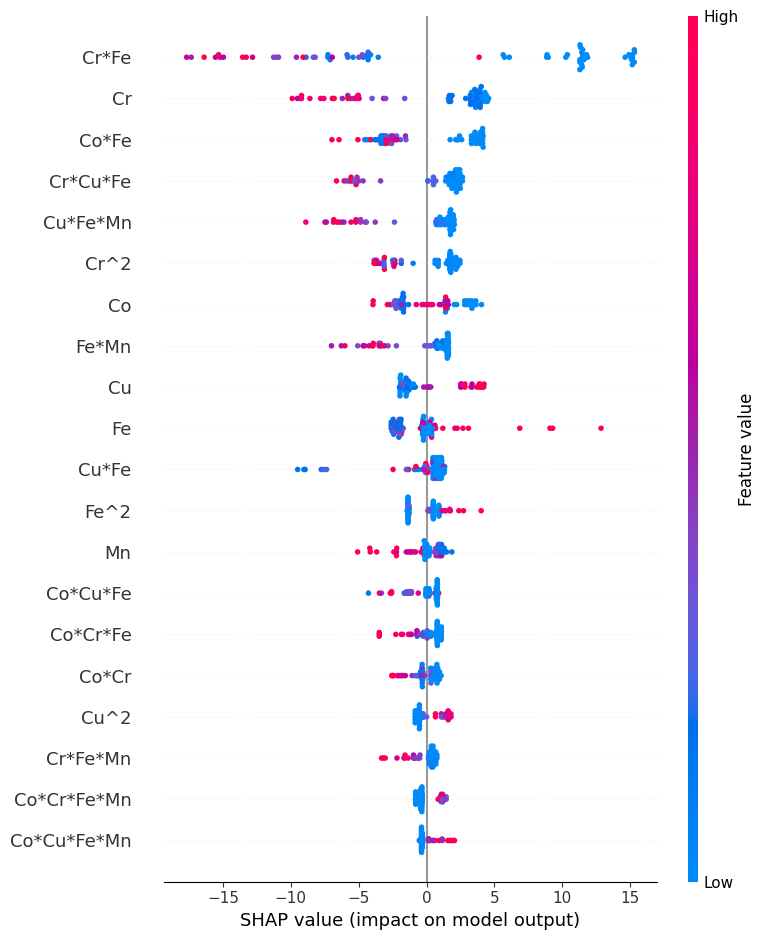

In [15]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(df.drop(columns=[TARGET]))

shap.summary_plot(shap_values, df.drop(columns=[TARGET]))

### 5.2 SHAP Feature Importance (Mean |SHAP value|)

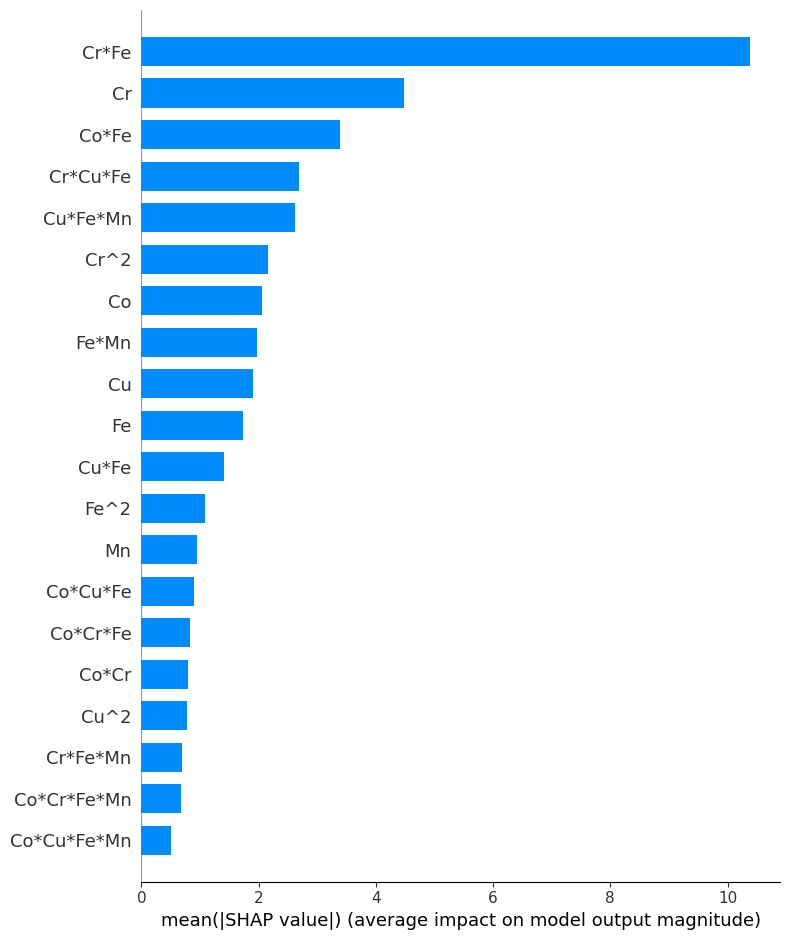

In [16]:
shap.summary_plot(shap_values, df.drop(columns=[TARGET]), plot_type="bar")

### 5.3 SHAP Dependence Plots — Top Two Features

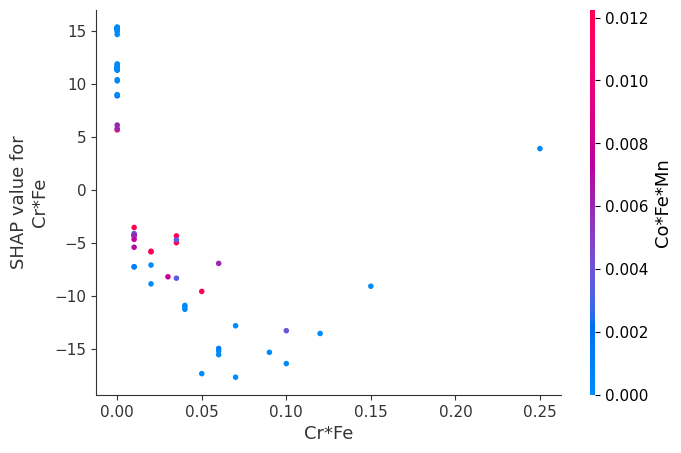

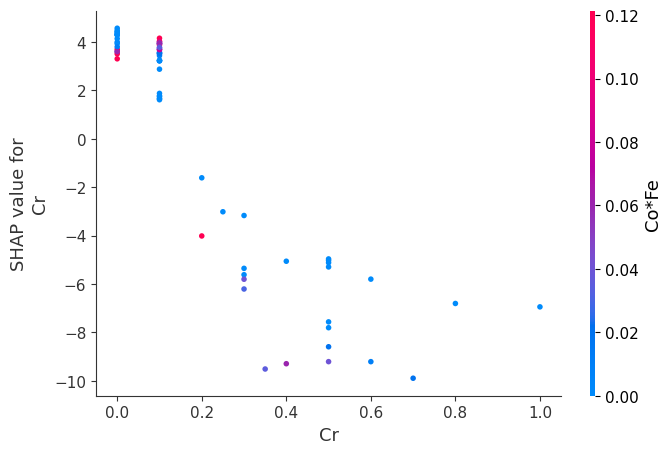

In [17]:
X_features = df.drop(columns=[TARGET])
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top2 = X_features.columns[np.argsort(mean_abs_shap)[::-1][:2]]

for feat in top2:
    shap.dependence_plot(feat, shap_values.values, X_features, feature_names=X_features.columns)

## 6. Conclusions

- The EDA — spanning integrity checks, distribution analysis, correlation heatmaps, pairplots,
  VIF, PCA, clustering, and an independent Lasso relevance check — consistently pointed toward
  the same story **before any model was trained**: individual elements matter little on their
  own, multi-element interactions (especially Cr·Fe) drive Overpotential, and there is a real
  measurement noise floor (~15–25 mV) that limits how far any model can go.
- **SHAP confirms this independently**, on a fitted model: Cr·Fe is the dominant driver, with
  high values pushing Overpotential up and low values pulling it down — the widest spread of
  any feature, followed by Cr and Co·Fe.
- **Actionable takeaway:** avoid alloy compositions that co-locate high Cr and Fe fractions when
  targeting lower overpotential.